In [51]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [52]:
df = pd.read_csv("airline_feature_engineered.csv")

df.shape

(389065, 44)

In [53]:
df.isnull().sum().sort_values(ascending=False)

Year                              0
Month                             0
Travel_Intensity                  0
Reward_Dependency                 0
Loyalty_Efficiency                0
City_FE                           0
Province_FE                       0
Country_FE                        0
Gender_Male                       0
Education_College                 0
Education_Doctor                  0
Education_High School or Below    0
Education_Master                  0
Marital Status_Married            0
Marital Status_Single             0
Loyalty Card_Nova                 0
Loyalty Card_Star                 0
Flight_Segment_Low                0
Flight_Segment_Medium             0
CLV_Segment_Medium                0
CLV_Segment_High                  0
Engagement_Score                  0
Premium_Customer                  0
Redeemed_Cost_Per_Point           0
Salary                            0
Total Flights                     0
Distance                          0
Points Accumulated          

## **Select Features for Clustering**

In [54]:
cluster_features = [

    'Total Flights',
    'Distance',
    'Points Accumulated',
    'Points Redeemed',
    'CLV',
    'Salary',

    'Tenure',
    'Membership_Age_Months',

    'Redemption_Ratio',
    'Avg_Distance_Per_Flight',
    'Points_Per_Flight',

    'Travel_Intensity',
    'Reward_Dependency',
    'Loyalty_Efficiency',

    'Engagement_Score'

]

In [55]:
X = df[cluster_features]

In [75]:

X.skew().sort_values(
    ascending=False
)

Redemption_Ratio           12.341619
Travel_Intensity           10.089626
Points Accumulated          6.664617
Reward_Dependency           5.790401
Points Redeemed             4.019956
Distance                    3.846973
Total Flights               3.188617
Engagement_Score            3.150039
Loyalty_Efficiency          3.046196
CLV                         3.026669
Salary                      1.097504
Points_Per_Flight           1.014702
Avg_Distance_Per_Flight     0.888942
Membership_Age_Months       0.247581
Tenure                      0.224148
dtype: float64

In [ ]:
skew_cols = [

    'Total Flights',
    'Distance',
    'Points Accumulated',
    'Points Redeemed',
    'CLV',
    'Travel_Intensity',
    'Reward_Dependency'

]

In [77]:
for col in skew_cols:

    X[col] = np.log1p(
        X[col]
    )

/var/folders/0d/zzcr1q6j13j_nz7xs4mpykgr0000gn/T/ipykernel_3201/184562611.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = np.log1p(


**Correlation Heatmap**

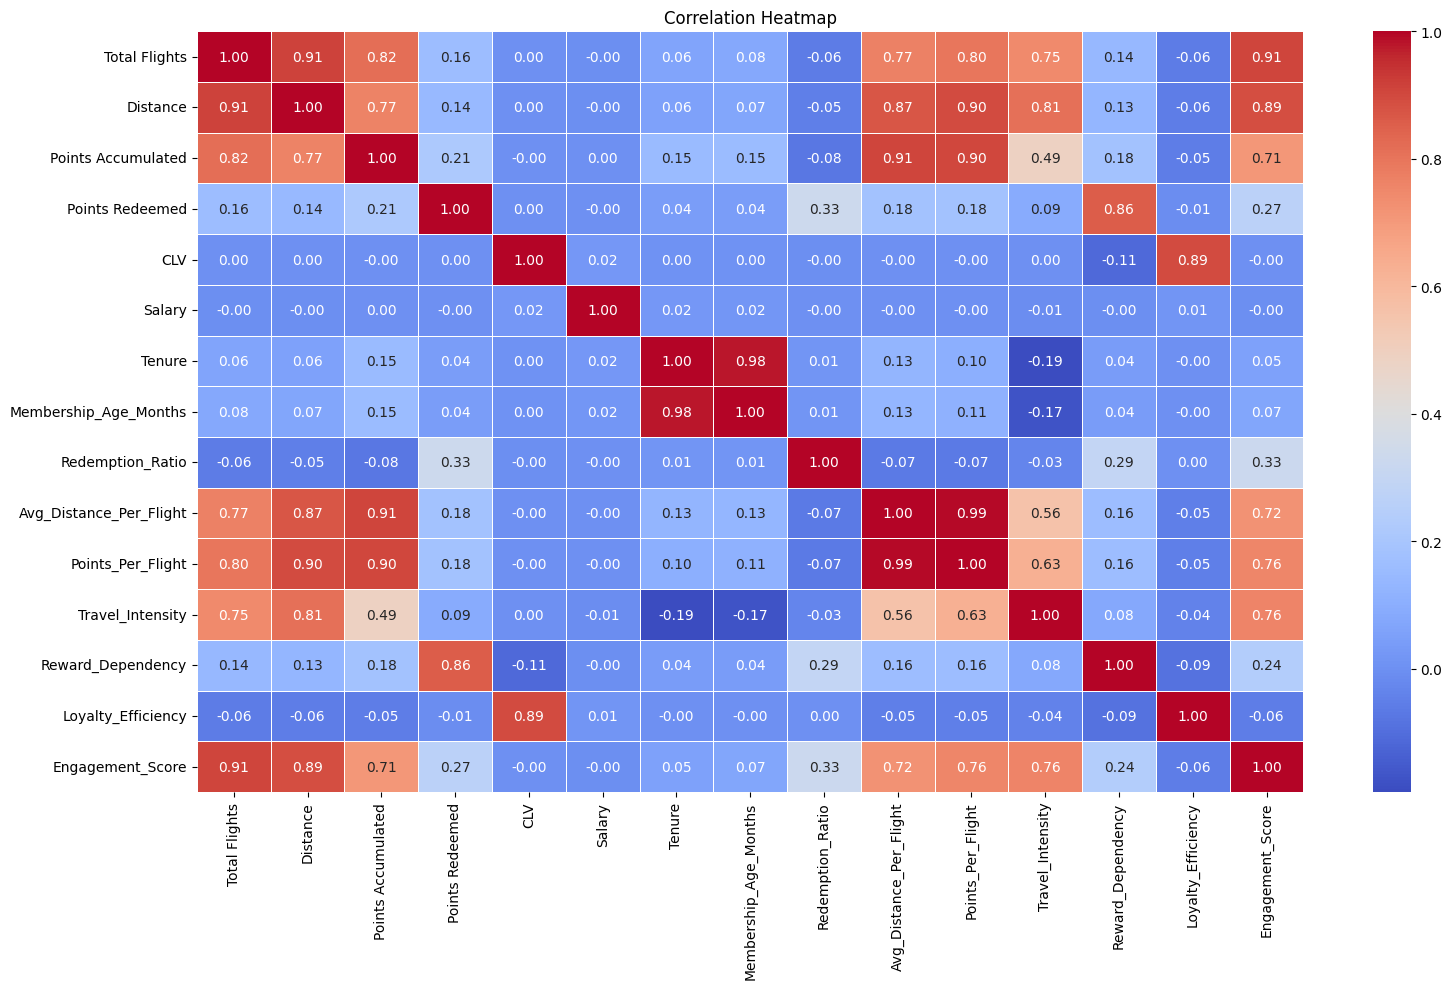

In [84]:
plt.figure(figsize=(16,10))

sns.heatmap(
    X.corr(),
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.show()

**Scaling**

In [87]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_scaled = scaler.fit_transform(X)

In [88]:
pd.DataFrame(
    X_scaled,
    columns=cluster_features
).describe().T

,count,mean,std,min,25%,50%,75%,max
Total Flights,389065.0,0.634390,0.910955,0.000000,0.000000,0.0,1.000000,11.433427
Distance,389065.0,0.624026,0.987994,0.000000,0.000000,0.0,1.000000,15.605040
Points Accumulated,389065.0,0.461474,0.506708,0.000000,0.000000,0.0,1.000000,1.434467
Points Redeemed,389065.0,0.381603,1.493648,0.000000,0.000000,0.0,0.000000,6.904751
CLV,389065.0,0.106075,0.804446,-1.371938,-0.458681,0.0,0.541319,3.292918
Salary,389065.0,-0.054167,0.546752,-0.768584,-0.768584,0.0,0.231416,4.130517
Tenure,389065.0,0.137507,0.632506,-0.666667,-0.333333,0.0,0.666667,1.333333
Membership_Age_Months,389065.0,0.051783,0.561185,-0.675000,-0.475000,0.0,0.525000,1.325000
Redemption_Ratio,389065.0,0.004366,0.051389,0.000000,0.000000,0.0,0.000000,1.000000
Avg_Distance_Per_Flight,389065.0,0.506448,0.639052,0.000000,0.000000,0.0,1.000000,2.565553


## **PCA**

In [58]:
pca = PCA()

X_pca = pca.fit_transform(
    X_scaled
)

In [59]:
explained_variance = pd.DataFrame({

    'PC':
    range(
        1,
        len(
            pca.explained_variance_ratio_
        ) + 1
    ),

    'Variance':
    pca.explained_variance_ratio_,

    'Cumulative':
    np.cumsum(
        pca.explained_variance_ratio_
    )

})

explained_variance

,PC,Variance,Cumulative
0,1,0.397837,0.397837
1,2,0.142129,0.539965
2,3,0.135206,0.675171
3,4,0.127549,0.802721
4,5,0.066589,0.869310
5,6,0.061561,0.930871
6,7,0.039632,0.970503
7,8,0.014330,0.984833
8,9,0.008918,0.993751
9,10,0.004183,0.997933


**Scree Plot**

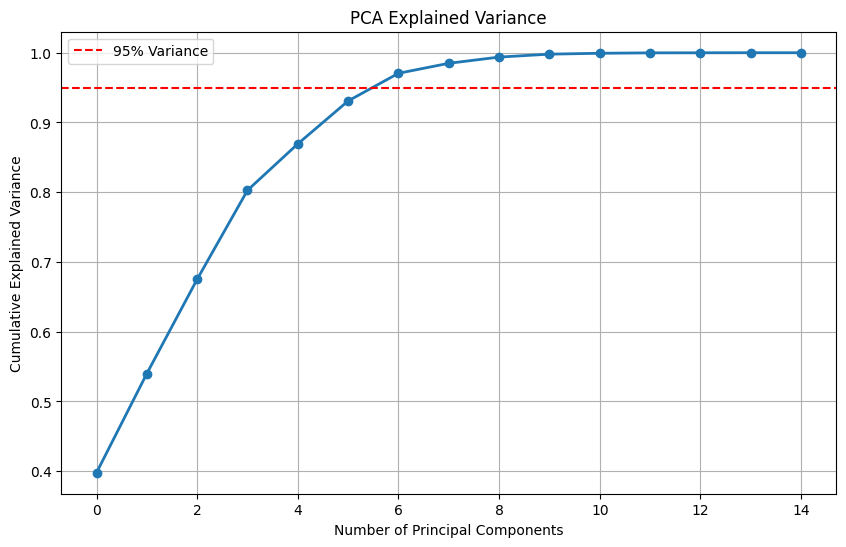

In [60]:
plt.figure(figsize=(10,6))

plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker='o',
    linewidth=2
)

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')

plt.axhline(
    y=0.95,
    color='r',
    linestyle='--',
    label='95% Variance'
)

plt.legend()
plt.grid(True)

plt.show()

In [89]:
# Keeping 95% Variance

pca = PCA(
    n_components=0.95,
    random_state=42
)

X_pca = pca.fit_transform(
    X_scaled
)

In [90]:
# Number of Components

print(
    "Original Features:",
    X_scaled.shape[1]
)

print(
    "PCA Components:",
    X_pca.shape[1]
)

Original Features: 15
PCA Components: 6


In [91]:
# Create PCA DataFrame

pca_df = pd.DataFrame(
    X_pca
)

**PCA Visualization 2D Scatter Plot**

In [92]:
pca_2d = PCA(
    n_components=2,
    random_state=42
)

X_pca_2d = pca_2d.fit_transform(
    X_scaled
)

pca_plot = pd.DataFrame(
    X_pca_2d,
    columns=[
        'PC1',
        'PC2'
    ]
)

In [93]:
pca_plot.head()

,PC1,PC2
0,-0.725055,0.132507
1,-1.520845,0.167408
2,6.379990,0.014932
3,0.109116,0.157879
4,-1.522125,0.166791


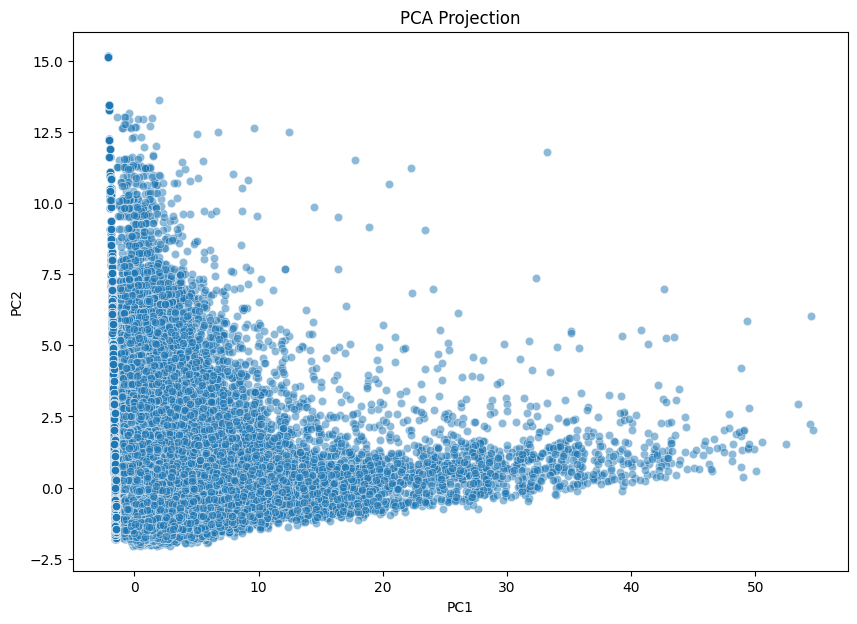

In [94]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_plot,
    x='PC1',
    y='PC2',
    alpha=0.5
)

plt.title(
    'PCA Projection'
)

plt.show()

## **K-Means**

In [95]:
inertia = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    model.fit(X_pca)

    inertia.append(
        model.inertia_
    )

**Elbow Method**

In [96]:
inertia = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    model.fit(X_pca)

    inertia.append(
        model.inertia_
    )

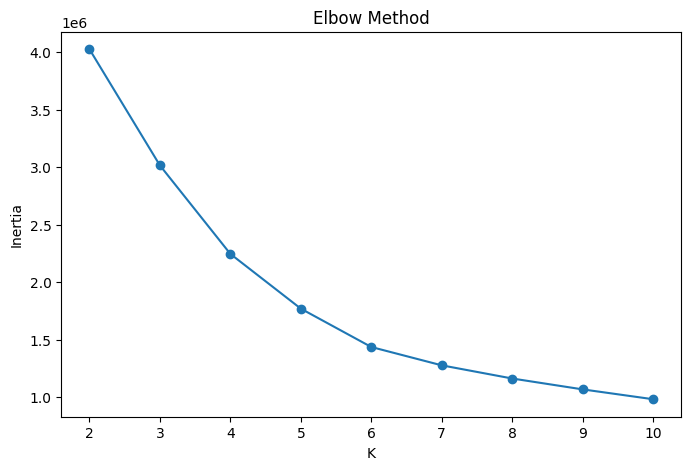

In [97]:
# Plot Elbow Curve

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker='o'
)

plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

**Silhouette Score**

In [98]:
# Cluster Validation Metrics
Rows = 389065
sample_size=10000
results = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(
        X_pca
    )

    sil = silhouette_score(
        X_pca,
        labels,
        sample_size=10000,
        random_state=42
    )

    db = davies_bouldin_score(
        X_pca,
        labels
    )

    ch = calinski_harabasz_score(
        X_pca,
        labels
    )

    results.append([

        k,
        sil,
        db,
        ch

    ])

**Metrics Table**

In [99]:
cluster_metrics = pd.DataFrame(

    results,

    columns=[

        'K',
        'Silhouette',
        'Davies_Bouldin',
        'Calinski_Harabasz'

    ]

)

cluster_metrics

,K,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,0.423317,1.306928,143027.061499
1,3,0.399612,1.064661,160673.018341
2,4,0.424263,0.847351,188284.655966
3,5,0.430928,0.797676,205372.605085
4,6,0.419751,0.788201,220538.444323
5,7,0.371627,0.887284,214832.691270
6,8,0.296258,0.971933,207769.715127
7,9,0.301734,0.990574,202214.875078
8,10,0.297799,1.000077,199191.068785


In [100]:
# Choose Best K
best_k = 5

# Final KMeans

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

df['Customer_Segment'] = (
    kmeans.fit_predict(
        X_pca
    )
)

**Segment Distribution**

In [101]:
df[
    'Customer_Segment'
].value_counts()

Customer_Segment
3    231135
2     93671
0     38185
4     23525
1      2549
Name: count, dtype: int64

## **Cluster Visualization**

In [102]:
pca_plot['Cluster'] = (
    df['Customer_Segment']
)

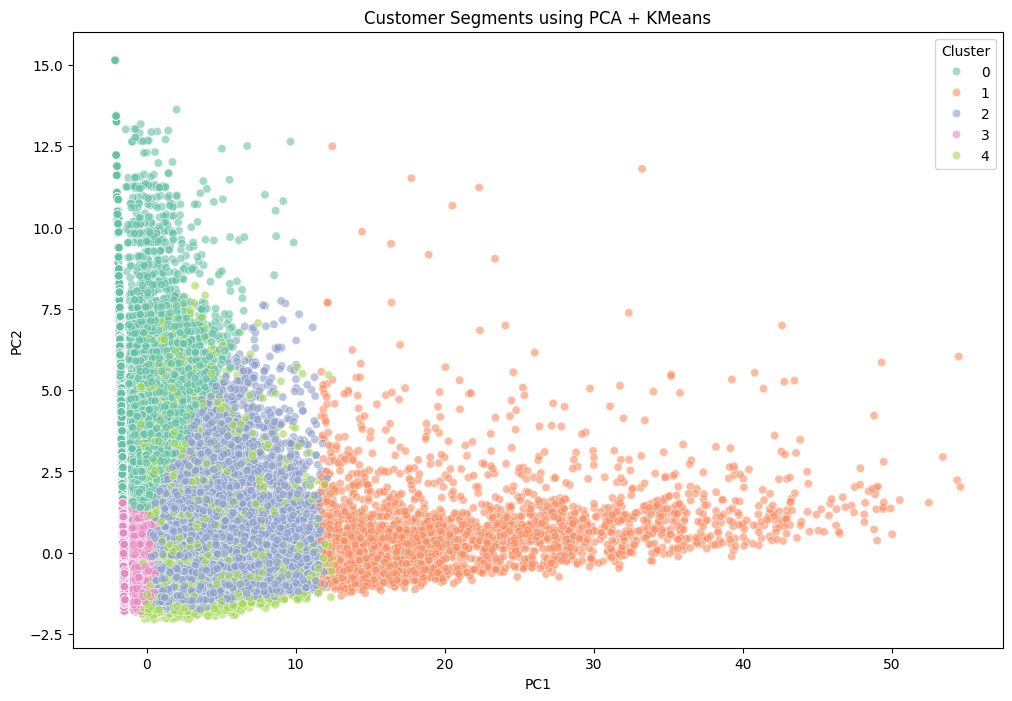

In [103]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=pca_plot,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set2',
    alpha=0.6
)

plt.title(
    'Customer Segments using PCA + KMeans'
)

plt.show()

**Plot Centroids**

In [104]:
kmeans_2d = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

labels_2d = kmeans_2d.fit_predict(
    X_pca_2d
)

centroids = (
    kmeans_2d.cluster_centers_
)

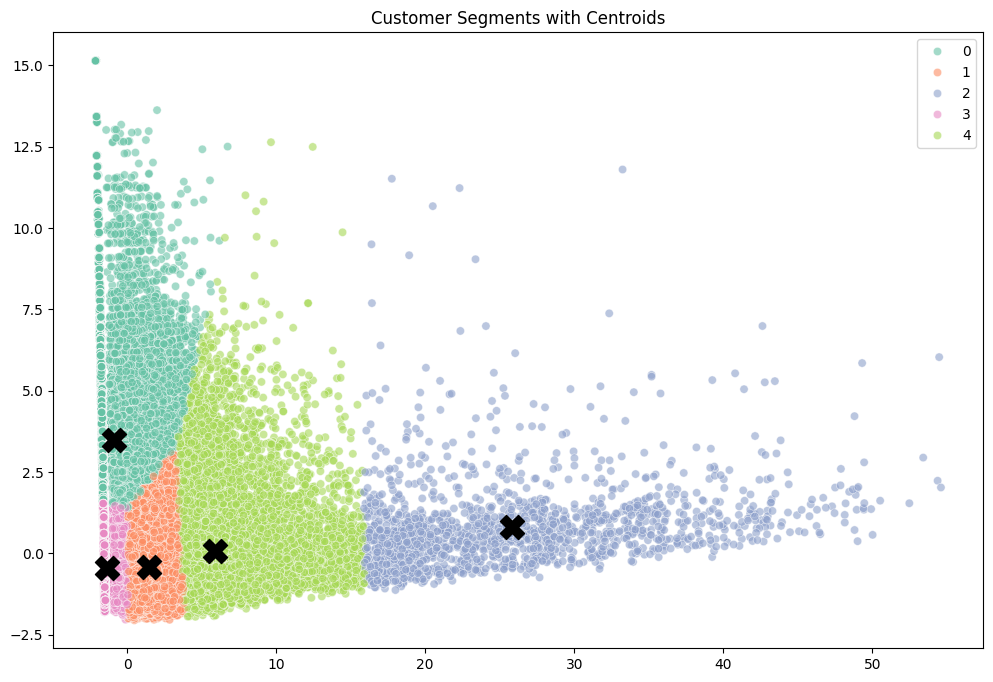

In [105]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    x=X_pca_2d[:,0],
    y=X_pca_2d[:,1],
    hue=labels_2d,
    palette='Set2',
    alpha=0.6
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    marker='X',
    s=300,
    c='black'
)

plt.title(
    'Customer Segments with Centroids'
)

plt.show()

**Segment Profiling**

In [106]:
segment_profile = (

    df.groupby(
        'Customer_Segment'
    )[cluster_features]

    .mean()

    .round(2)

)

segment_profile

,Total Flights,Distance,Points Accumulated,Points Redeemed,CLV,Salary,Tenure,Membership_Age_Months,Redemption_Ratio,Avg_Distance_Per_Flight,Points_Per_Flight,Travel_Intensity,Reward_Dependency,Loyalty_Efficiency,Engagement_Score
Customer_Segment,,,,,,,,,,,,,,,
0,0.02,0.01,924.12,0.99,23418.09,59275.53,2.45,29.37,0.00,289.10,290.21,0.00,0.00,22893.90,0.01
1,0.41,0.32,31558.16,61.82,8118.81,55938.44,0.00,4.52,0.00,1612.87,2294.67,0.32,0.01,5867.79,0.26
2,0.11,0.08,5558.53,0.00,6802.28,59025.11,2.56,31.14,0.00,1231.54,1246.08,0.03,0.00,6137.05,0.07
3,0.01,0.00,334.72,0.00,5931.78,59591.36,2.34,28.03,0.00,140.47,140.65,0.00,0.00,5879.27,0.01
4,0.07,0.05,3518.84,514.56,7835.92,59332.62,2.77,33.25,0.07,891.80,899.93,0.02,0.10,7311.60,0.07


**Segment Profiling Heatmap**

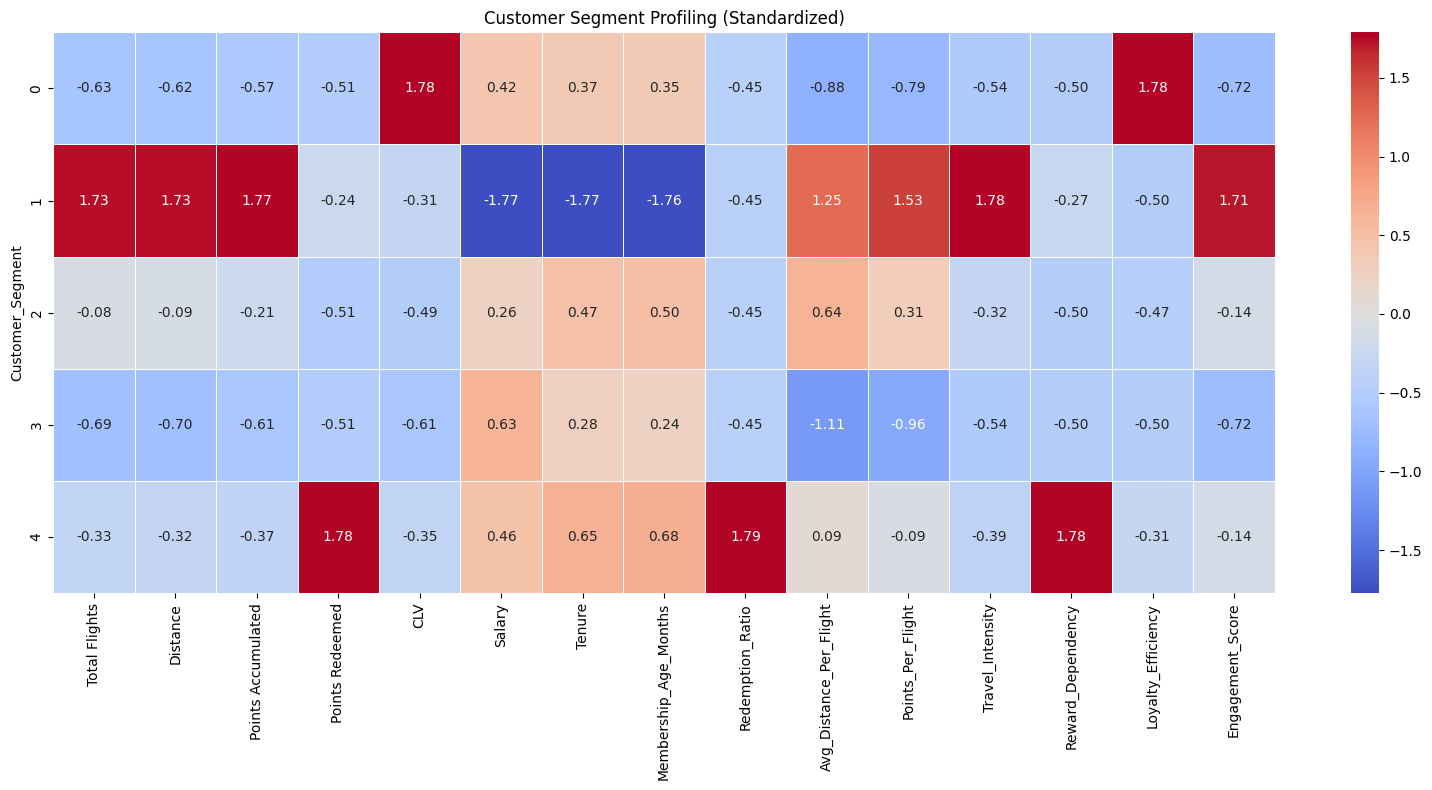

In [111]:
segment_profile_scaled = (
    segment_profile - segment_profile.mean()
) / segment_profile.std()

plt.figure(figsize=(16,8))

sns.heatmap(
    segment_profile_scaled,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Customer Segment Profiling (Standardized)')

plt.tight_layout()
plt.show()

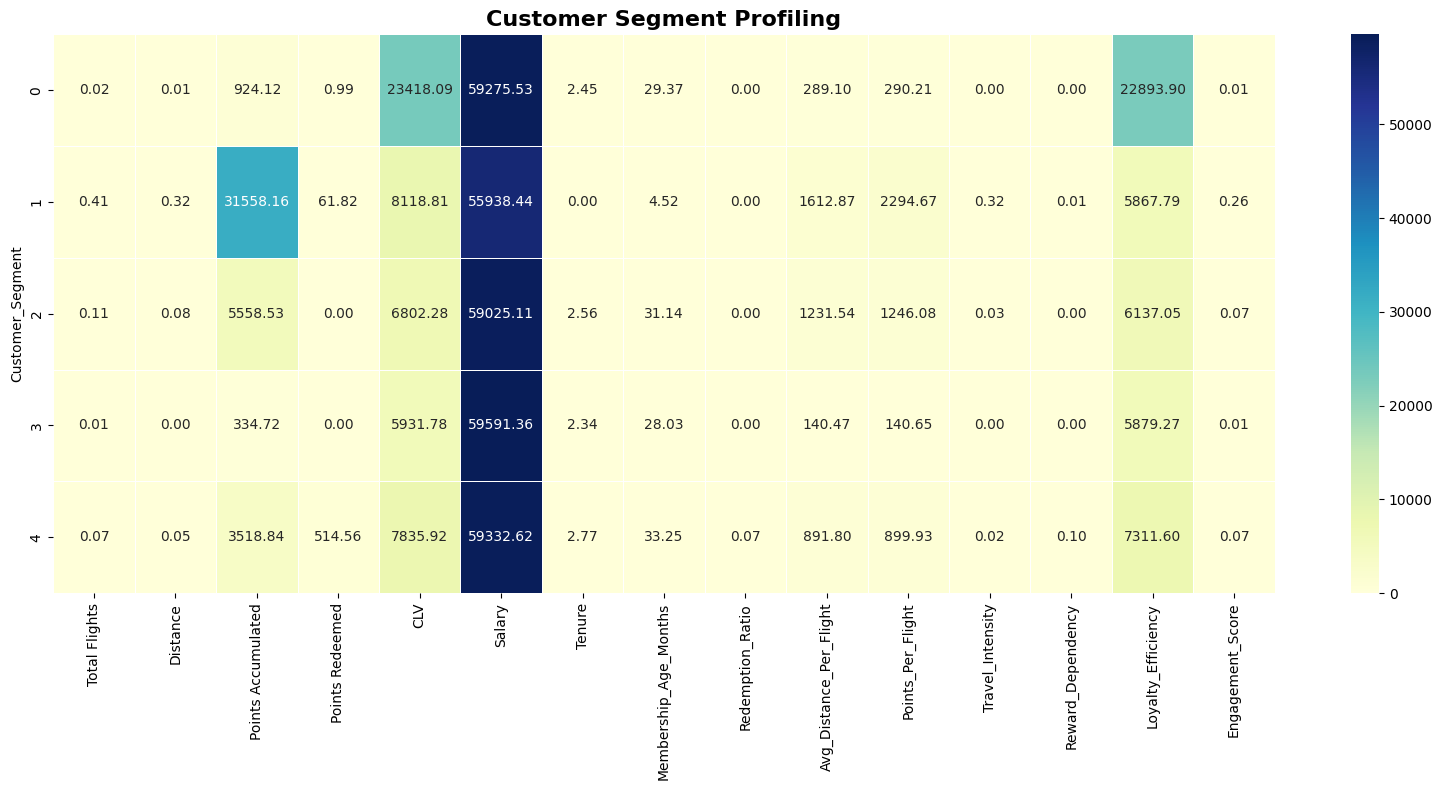

In [108]:
plt.figure(figsize=(16,8))

sns.heatmap(
    segment_profile,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title(
    'Customer Segment Profiling',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

**Give Business Names**

In [112]:
segment_map = {

    0:
    'Inactive Customers',

    1:
    'Frequent Flyers',

    2:
    'Premium Customers',

    3:
    'Reward Seekers',

    4:
    'High Value At-Risk'

}

In [113]:
df['Customer_Segment_Name'] = (

    df['Customer_Segment']
    .map(segment_map)

)

In [117]:
df['Customer_Segment_Name'].unique()

array(['Reward Seekers', 'High Value At-Risk', 'Premium Customers',
       'Inactive Customers', 'Frequent Flyers'], dtype=object)

In [118]:
df.to_csv(
    'airline_segmented.csv',
    index=False
)

print(
    "airline_segmented.csv saved successfully!"
)

airline_segmented.csv saved successfully!
